<div style="
    background: linear-gradient(90deg, #3F0047, #410075);
    padding: 60px 20px;
    margin: 40px auto;
    border-radius: 18px;
    box-shadow: 0 3px 6px rgba(0, 0, 0, 0.3);
    border: 4px solid #ffffff;
    text-align: center;
    width: 95%;
    box-sizing: border-box;
    overflow: visible;
">
    <h1 style="
        color: white !important;
        font-family: 'Arial Black', Arial, sans-serif;
        font-size: 50px;
        font-weight: 900;
        margin: 0 !important;
        padding: 0 !important;
        line-height: 1 !important;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.7);
        display: block;
    ">
        Customer Churn
    </h1>
</div>


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
This notebook focuses on the Playground Series S6E3 competition.<br>
</div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Import Libraries</b></div>

In [4]:
import numpy as np
import pandas as pd
import math

import matplotlib.pyplot as plt
import seaborn as sns
cmap = sns.cubehelix_palette(as_cmap=True)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss
from sklearn.calibration import CalibrationDisplay
import torch
DEVICE = 'GPU' if torch.cuda.is_available() else 'CPU'
print(f"Using device: {DEVICE}")

Using device: CPU


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Read and Examine Dataset</b></div>

In [5]:
df_train = pd.read_csv(r"Data\train.csv")
df_test = pd.read_csv(r"Data\test.csv")
df_original = pd.read_csv(r"Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [6]:
print("- The Train set's shape is", df_train.shape[0], "rows and", df_train.shape[1], "columns.")
print("- The Test set's shape is", df_test.shape[0], "rows and", df_test.shape[1], "columns.")
print("- The Original set's shape is", df_original.shape[0], "rows and", df_original.shape[1], "columns.")

- The Train set's shape is 594194 rows and 21 columns.
- The Test set's shape is 254655 rows and 20 columns.
- The Original set's shape is 7043 rows and 21 columns.


In [7]:
df_train = df_train.drop("id", axis=1)

In [8]:
TARGET = "Churn"
categorical_features = (df_train.select_dtypes('object').columns.drop(TARGET).to_list()) + ['SeniorCitizen']
numerical_features = df_train.select_dtypes(include=['int', 'float']).columns.drop('SeniorCitizen').tolist()

In [9]:
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce').astype('float64')

## Feature Cardinality

In [10]:
print("=== Unique Numeric Data ===")
print(df_train[numerical_features].nunique(),'\n')
print("== Unique Categorical Data ==")
print(df_train[categorical_features].nunique())

=== Unique Numeric Data ===
tenure               72
MonthlyCharges     1921
TotalCharges      31910
dtype: int64 

== Unique Categorical Data ==
gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
SeniorCitizen       2
dtype: int64


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Feature Engineering</b></div>

In [11]:
le = LabelEncoder()
df_original[TARGET] = le.fit_transform(df_original[TARGET])

In [12]:
base_features = df_train.select_dtypes('object').columns.drop(TARGET).to_list()

In [13]:
def compute_original_stats(df):
    df = df.copy()
    
    for col in base_features:
        if col not in df_original.columns:
            continue

        means = df_original.groupby(col)[TARGET].mean()
        medians = df_original.groupby(col)[TARGET].median()
        stds = df_original.groupby(col)[TARGET].std().fillna(0)
        skews = df_original.groupby(col)[TARGET].skew().fillna(0)
        counts = df_original.groupby(col)[TARGET].count()
        
        df[f'{col}_mean'] = df[col].map(means).fillna(df_original[TARGET].mean())
        df[f'{col}_median'] = df[col].map(medians).fillna(df_original[TARGET].median())
        df[f'{col}_std'] = df[col].map(stds).fillna(0)
        df[f'{col}_skew'] = df[col].map(skews).fillna(0)
        df[f'{col}_count'] = df[col].map(counts).fillna(0)
    
    return df

In [14]:
df_train = compute_original_stats(df_train)
df_test = compute_original_stats(df_test)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>KFOLD Catboost</b></div>

In [15]:
le = LabelEncoder()
df_train[TARGET] = le.fit_transform(df_train[TARGET])

X = df_train.drop([TARGET], axis=1).copy()
y = df_train[TARGET].copy()
X_test = df_test.drop(['id'], axis=1).copy()

In [ ]:
%%time
cat_params = {
    'iterations': 1800,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 200,
    'early_stopping_rounds': 100,
    'task_type': DEVICE,
    'cat_features': categorical_features
}

n_folds = 5

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_preds = np.zeros(len(df_train))
y_test_preds = np.zeros(len(df_test))
fold_scores = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n===== Fold {fold + 1} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(**cat_params)
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

    val_probs = model.predict_proba(X_val)[:, 1]
    fold_test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    y_test_preds += fold_test_probs / n_folds

    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

total_oof_score = roc_auc_score(y, oof_preds) 
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")


===== Fold 1 =====
0:	test: 0.8983555	best: 0.8983555 (0)	total: 510ms	remaining: 15m 17s
200:	test: 0.9127706	best: 0.9127706 (200)	total: 1m 2s	remaining: 8m 17s
400:	test: 0.9137808	best: 0.9137808 (400)	total: 2m 2s	remaining: 7m 6s
600:	test: 0.9146549	best: 0.9146549 (600)	total: 3m 3s	remaining: 6m 5s
800:	test: 0.9151491	best: 0.9151491 (800)	total: 4m 6s	remaining: 5m 7s
1000:	test: 0.9154204	best: 0.9154204 (1000)	total: 5m 10s	remaining: 4m 7s
1200:	test: 0.9156432	best: 0.9156432 (1200)	total: 6m 15s	remaining: 3m 7s
1400:	test: 0.9157682	best: 0.9157682 (1400)	total: 7m 23s	remaining: 2m 6s
1600:	test: 0.9158545	best: 0.9158545 (1600)	total: 8m 29s	remaining: 1m 3s
1799:	test: 0.9159157	best: 0.9159157 (1799)	total: 9m 33s	remaining: 0us

bestTest = 0.9159156595
bestIteration = 1799

Fold 1 ROC-AUC Score: 0.91592

===== Fold 2 =====
0:	test: 0.9002007	best: 0.9002007 (0)	total: 334ms	remaining: 10m


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>ROC CURVE</b></div>

Train AUC score is: 0.914822208593197


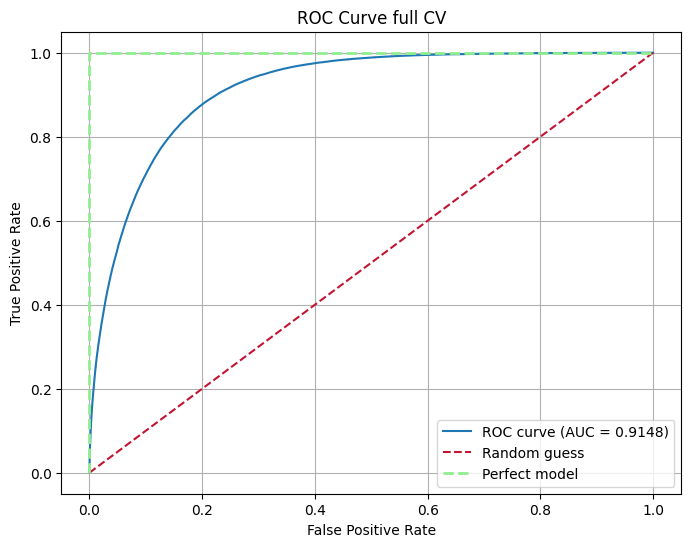

In [ ]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)

auc_score = auc(fpr, tpr)
print("Train AUC score is:", auc_score)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='#c31432', label='Random guess')
plt.plot([0, 0, 1], [0, 1, 1], color='lightgreen', linestyle='--', linewidth=2, label='Perfect model')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve full CV")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Feature Importance</b></div>

In [ ]:
df_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.title("Top 15 Feature Importance") 
ax = sns.barplot(x='Importance', y='Feature', data=df_importance, color='#3F0047')

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #3F0047, #410075); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Sumission</b></div>

In [ ]:
submission = pd.DataFrame({'id': df_test['id'], 'Churn': y_test_preds})
submission.to_csv('submission_cat.csv', index=False)
submission.head()

,id,Churn
0,594194,0.067043
1,594195,0.001710
2,594196,0.095029
3,594197,0.003622
4,594198,0.494499
